## set up

In [1]:
import numpy as np
from numpy import trapezoid
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from astropy.io import fits
import astropy.units as u
from astropy.visualization import ZScaleInterval
from astropy.constants import G
import os

In [2]:
formatter = ScalarFormatter(useOffset=False)

### read in SRT data file & data cube (Q1)

In [3]:
# srt data

input_file = ('/content/drive/MyDrive/astro465/lab5/data5/radio3_data_lauren.rad')
output_file = ('/content/drive/MyDrive/astro465/lab5/data5/processed_lab5_data.rad')

with open(input_file, 'r') as infile, open(output_file, 'w') as outfile:
    for line in infile:
        if not line.startswith('*'):
            line_proc = ','.join(line.split())
            outfile.write(line_proc + '\n')
        else:
            outfile.write(line)

data = pd.read_csv(output_file,
                   sep=',',
                   comment='*',
                   header=None,
                   names=['time', 'az', 'el', 'az_offset', 'el_offset',
                          'freq_1_bin', 'channel_width', 'spectrometer_mode',
                          'num_channels'] + [f'freq_channel_{i+1}' for i in range(156)])


In [4]:
# data cube

file = ('/content/drive/MyDrive/astro465/lab5/data5/LDSfull.fits')
cube = fits.open(file)
cube_data = cube[0].data
cube_data.shape

(389, 361, 720)

### data exploration

In [5]:
data.head(12)

,time,az,el,az_offset,el_offset,freq_1_bin,channel_width,spectrometer_mode,num_channels,freq_channel_1,...,freq_channel_147,freq_channel_148,freq_channel_149,freq_channel_150,freq_channel_151,freq_channel_152,freq_channel_153,freq_channel_154,freq_channel_155,freq_channel_156
0,2025:315:21:48:09,0.0,0.0,0.0,0.0,1419.75,0.007812,1,64,380.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025:315:21:48:17,0.0,0.0,0.0,0.0,1419.79,0.007812,4,156,171.4,...,18800.5,18391.0,18869.5,12540.6,9135.7,6174.8,3569.0,1866.1,1036.3,666.4
2,2025:315:21:51:58,194.9,34.2,0.0,0.0,1419.79,0.007812,4,156,208.8,...,16104.6,16158.2,15932.3,11147.3,8151.1,5133.0,3029.8,1651.7,855.5,556.4
3,2025:315:21:52:56,195.3,64.1,0.0,30.0,1419.79,0.007812,4,156,111.7,...,16620.7,16179.4,15716.7,10893.9,8249.1,5301.3,3110.5,1690.7,951.9,654.1
4,2025:315:21:53:04,195.3,64.1,0.0,30.0,1419.79,0.007812,4,156,224.9,...,16824.8,17291.4,17329.4,12153.9,8385.6,5577.4,3216.1,1706.9,912.6,563.4
5,2025:315:21:53:12,195.3,64.1,0.0,30.0,1419.79,0.007812,4,156,202.7,...,16501.5,16060.3,15981.6,11159.7,8094.7,5192.6,3124.5,1655.5,872.4,549.4
6,2025:315:21:53:19,195.3,64.1,0.0,30.0,1419.79,0.007812,4,156,36.7,...,2441.3,2442.4,2382.2,1635.8,1219.4,785.7,448.8,234.4,124.5,75.9
7,2025:315:21:54:11,195.8,34.1,0.0,0.0,1419.79,0.007812,4,156,20.8,...,2415.0,2379.5,2382.1,1687.8,1200.0,786.1,471.7,252.9,140.1,91.2
8,2025:315:21:54:19,195.8,34.1,0.0,0.0,1419.69,0.007812,4,156,22.7,...,2429.5,2428.1,2436.1,1690.3,1207.6,787.4,458.3,249.9,133.1,88.2
9,2025:315:21:54:27,195.8,34.1,0.0,0.0,1419.71,0.007812,4,156,29.9,...,2378.1,2379.5,2363.4,1626.6,1225.7,796.9,455.4,247.5,128.6,81.8


In [6]:
data_cal = data[:10]
data = data[10:]
data_cal.shape, data.shape

((10, 165), (381, 165))

In [7]:
data.head()

,time,az,el,az_offset,el_offset,freq_1_bin,channel_width,spectrometer_mode,num_channels,freq_channel_1,...,freq_channel_147,freq_channel_148,freq_channel_149,freq_channel_150,freq_channel_151,freq_channel_152,freq_channel_153,freq_channel_154,freq_channel_155,freq_channel_156
10,2025:315:21:54:34,195.8,34.1,0.0,0.0,1419.71,0.007812,4,156,39.9,...,2396.7,2445.2,2384.7,1640.7,1202.6,765.3,436.7,231.0,118.5,68.9
11,2025:315:21:54:42,195.8,34.1,0.0,0.0,1419.71,0.007812,4,156,19.5,...,2372.8,2345.5,2380.1,1638.3,1191.7,785.7,470.1,255.3,140.3,94.3
12,2025:315:21:54:50,195.8,34.1,0.0,0.0,1419.71,0.007812,4,156,62.8,...,2384.5,2340.3,2392.8,1593.5,1185.9,740.1,418.5,209.1,98.8,52.1
13,2025:315:21:54:59,196.0,34.1,0.0,0.0,1419.71,0.007812,4,156,27.1,...,2365.0,2409.4,2415.1,1652.7,1228.0,778.8,438.7,247.2,131.1,84.7
14,2025:315:21:55:06,196.0,34.1,0.0,0.0,1419.71,0.007812,4,156,34.8,...,2414.0,2425.2,2405.3,1648.1,1207.9,777.6,450.2,240.6,124.8,77.2


from the .rad file:
- `tsys  2356 calcons 0.15 trecvr 2336 tload  103 tspill   20`

## data analysis

### time-averaged spectra (Q1)

In [8]:
spectral_columns = [col for col in data.columns if col.startswith('freq_channel_')]

In [9]:
# calculate average for each frequency channel

average_spectra = data[spectral_columns].mean(axis=0)
average_spectra

,0
freq_channel_1,28.278740
freq_channel_2,40.715223
freq_channel_3,87.543832
freq_channel_4,197.074016
freq_channel_5,400.126509
...,...
freq_channel_152,781.042257
freq_channel_153,455.828871
freq_channel_154,244.272966
freq_channel_155,131.039370


In [10]:
data['freq_1_bin'].iloc[0]

np.float64(1419.71)

In [11]:
freq_1 = 1419.71
width = 0.0078125

freq_array = freq_1 + np.arange(156) * width
freq_array

array([1419.71     , 1419.7178125, 1419.725625 , 1419.7334375,
       1419.74125  , 1419.7490625, 1419.756875 , 1419.7646875,
       1419.7725   , 1419.7803125, 1419.788125 , 1419.7959375,
       1419.80375  , 1419.8115625, 1419.819375 , 1419.8271875,
       1419.835    , 1419.8428125, 1419.850625 , 1419.8584375,
       1419.86625  , 1419.8740625, 1419.881875 , 1419.8896875,
       1419.8975   , 1419.9053125, 1419.913125 , 1419.9209375,
       1419.92875  , 1419.9365625, 1419.944375 , 1419.9521875,
       1419.96     , 1419.9678125, 1419.975625 , 1419.9834375,
       1419.99125  , 1419.9990625, 1420.006875 , 1420.0146875,
       1420.0225   , 1420.0303125, 1420.038125 , 1420.0459375,
       1420.05375  , 1420.0615625, 1420.069375 , 1420.0771875,
       1420.085    , 1420.0928125, 1420.100625 , 1420.1084375,
       1420.11625  , 1420.1240625, 1420.131875 , 1420.1396875,
       1420.1475   , 1420.1553125, 1420.163125 , 1420.1709375,
       1420.17875  , 1420.1865625, 1420.194375 , 1420.2

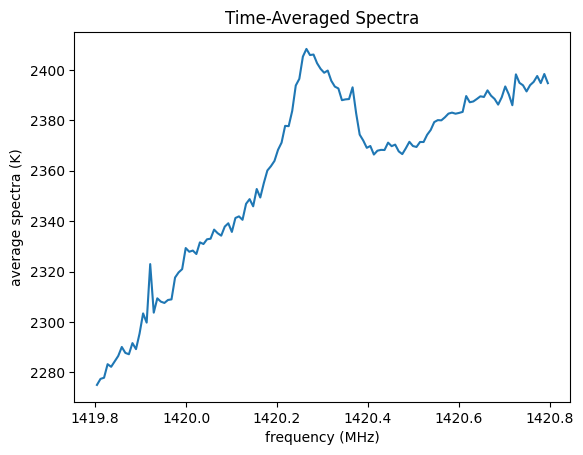

In [12]:
mask=(freq_array>1419.8) & (freq_array<1420.8)
x=freq_array[mask]
y=average_spectra[mask]
plt.plot(x,y)
plt.xlabel('frequency (MHz)')
plt.ylabel('average spectra (K)')
plt.title('Time-Averaged Spectra')
ax = plt.gca()
ax.xaxis.set_major_formatter(formatter)
plt.show()

### conver to topocentric radial velocity (Q2)

$$v_r \cong \frac{c(f_0 - f)}{f}$$
where c is the speed of light, $f_0$ is the rest frequency (in our case, frequency of the 21 cm line of atomic hydrogen), and $f$ is the observed frequency in our data

In [13]:
# convert freq to radial velocity

c = 299792.458  # km/s
f0 = 1420.4     # MHz

radial_velocity = c * (f0-freq_array)/freq_array
radial_velocity

array([ 145.70355637,  144.05304043,  142.40254265,  140.75206303,
        139.10160158,  137.4511583 ,  135.80073317,  134.15032621,
        132.49993742,  130.84956678,  129.19921431,  127.54888   ,
        125.89856386,  124.24826587,  122.59798605,  120.94772439,
        119.29748088,  117.64725554,  115.99704836,  114.34685934,
        112.69668848,  111.04653578,  109.39640123,  107.74628485,
        106.09618662,  104.44610655,  102.79604464,  101.14600089,
         99.4959753 ,   97.84596786,   96.19597858,   94.54600745,
         92.89605448,   91.24611967,   89.59620301,   87.9463045 ,
         86.29642416,   84.64656196,   82.99671792,   81.34689204,
         79.6970843 ,   78.04729472,   76.3975233 ,   74.74777002,
         73.0980349 ,   71.44831793,   69.79861912,   68.14893845,
         66.49927594,   64.84963157,   63.20000536,   61.5503973 ,
         59.90080739,   58.25123562,   56.60168201,   54.95214655,
         53.30262923,   51.65313006,   50.00364904,   48.35418

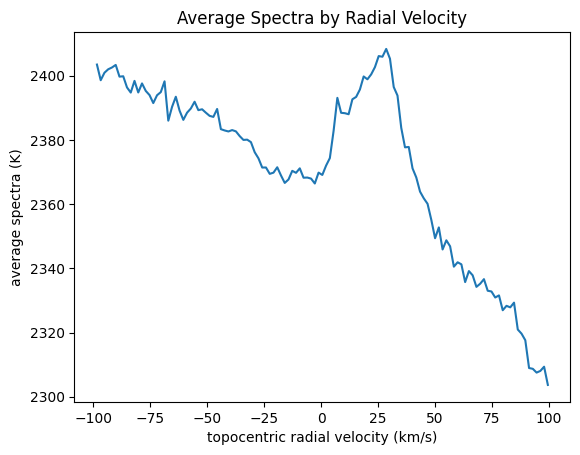

In [14]:
mask=(radial_velocity>-100) & (radial_velocity<100)
x=radial_velocity[mask]
y=average_spectra[mask]
plt.plot(x,y)
plt.xlabel('topocentric radial velocity (km/s)')
plt.ylabel('average spectra (K)')
plt.title('Average Spectra by Radial Velocity')
plt.show()

### linear polynomial fit (Q3)

In [15]:
#fit_velocity = radial_velocity[(radial_velocity<-100)|(radial_velocity>120)]
#fit_spectra = average_spectra[(radial_velocity<-100)|(radial_velocity>120)]
fit_velocity = radial_velocity[average_spectra<2000]
fit_spectra = average_spectra[average_spectra<2000]

fit = np.polyfit(fit_velocity, fit_spectra, 1)
baseline_fit = np.polyval(fit, radial_velocity)

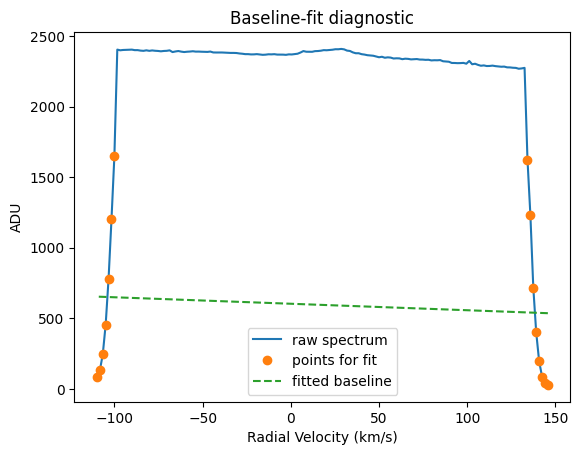

In [16]:
plt.plot(radial_velocity, average_spectra, label='raw spectrum')
plt.plot(fit_velocity, fit_spectra, 'o', label='points for fit')
plt.plot(radial_velocity, baseline_fit, '--', label='fitted baseline')
plt.xlabel('Radial Velocity (km/s)')
plt.ylabel('ADU')
plt.legend()
plt.title('Baseline-fit diagnostic')
plt.show()

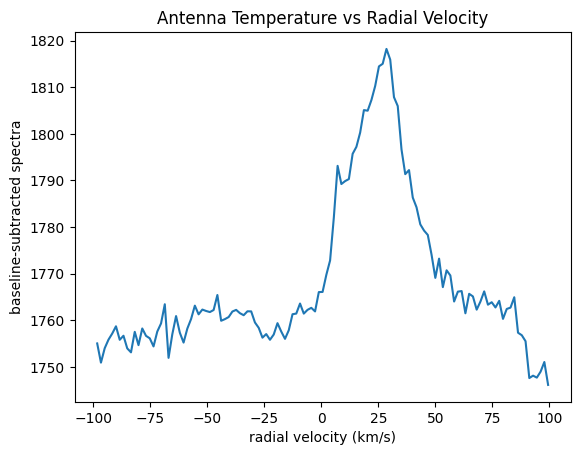

In [17]:
baseline_subtracted = average_spectra - baseline_fit

mask=(radial_velocity>-100) & (radial_velocity<100)
x=radial_velocity[mask]
y=baseline_subtracted[mask]
plt.plot(x, y, label='baseline-subtracted')
plt.xlabel('radial velocity (km/s)')
plt.ylabel('baseline-subtracted spectra')
plt.title('Antenna Temperature vs Radial Velocity')
plt.show()

### velocity correction (Q4)

### final sprectra plot (Q5)

### estimate velocity (Q6)

#### velocity at HI spectra peak ($V_{r,2}$)

In [18]:
# galactic 20 0
galactic_20 = data[(data['time'] >= '2025:315:21:54:34') & (data['time'] <= '2025:315:21:59:29')]

In [19]:
# galactic 26 0
galactic_26 = data[(data['time'] >= '2025:315:21:59:56') & (data['time'] <= '2025:315:22:04:51')]

In [20]:
# galactic 32 0
galactic_32 = data[(data['time'] >= '2025:315:22:05:19') & (data['time'] <= '2025:315:22:10:15')]

In [21]:
# galactic 38 0
galactic_38 = data[(data['time'] >= '2025:315:22:10:42') & (data['time'] <= '2025:315:22:15:39')]

In [22]:
# galactic 44 0
galactic_44 = data[(data['time'] >= '2025:315:22:16:17') & (data['time'] <= '2025:315:22:21:17')]

In [23]:
# galactic 50 0
galactic_50 = data[(data['time'] >= '2025:315:22:21:48') & (data['time'] <= '2025:315:22:26:39')]

In [24]:
# galactic 56 0
galactic_56 = data[(data['time'] >= '2025:315:22:27:10') & (data['time'] <= '2025:315:22:32:04')]

In [25]:
# galactic 62 0
galactic_62 = data[(data['time'] >= '2025:315:22:32:36') & (data['time'] <= '2025:315:22:37:33')]

In [26]:
# galactic 68 0
galactic_68 = data[(data['time'] >= '2025:315:22:38:09') & (data['time'] <= '2025:315:22:43:04')]

In [27]:
# galactic 74 0
galactic_74 = data[(data['time'] >= '2025:315:22:43:47') & (data['time'] <= '2025:315:22:48:40')]

#### plot

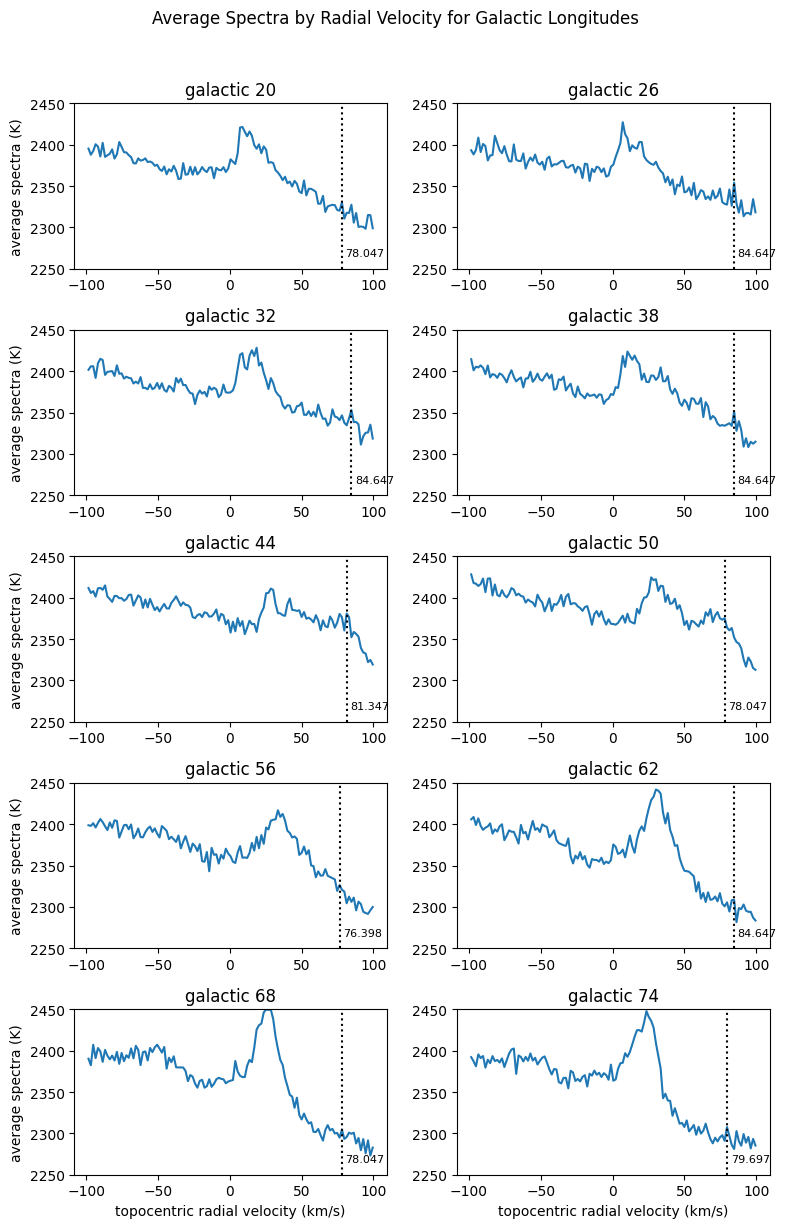

In [28]:
galactic_numbers = [20, 26, 32, 38, 44, 50, 56, 62, 68, 74]
vr2 = []

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(8, 12),
    sharex=False)

axes = axes.flatten()

mask = (radial_velocity>-100) & (radial_velocity<100)
x = radial_velocity[mask]

mask_peak = (radial_velocity>=75) & (radial_velocity<=100)
x_peak = radial_velocity[mask_peak]

for i, num in enumerate(galactic_numbers):

    current_df = globals()[f'galactic_{num}']

    y = (current_df[spectral_columns].mean(axis=0))[mask]

    y_peak = (current_df[spectral_columns].mean(axis=0))[mask_peak]
    max_index_peak = np.argmax(y_peak)
    peak_velocity = x_peak[max_index_peak]

    vr2.append(peak_velocity)

    ax = axes[i]
    ax.plot(x, y, color='C0')
    ax.set_title(f'galactic {num}', fontsize=12)

    ax.set_ylim(2250, 2450)

    ax.axvline(
        x=peak_velocity,
        color='black',
        linestyle='dotted')

    ax.text(
        peak_velocity + 2.5, 2275,
        f'{peak_velocity:.3f}',
        fontsize=8,
        color='black',
        ha='left',
        va='top')

    # set y-axis label for the left column plots
    if i % 2 == 0:
        ax.set_ylabel('average spectra (K)', fontsize=10)

for ax in axes[-2:]:
    ax.set_xlabel('topocentric radial velocity (km/s)', fontsize=10)

fig.suptitle('Average Spectra by Radial Velocity for Galactic Longitudes', fontsize=12, y=1.02)

plt.tight_layout()
plt.show()

In [29]:
vr2

[np.float64(78.04729472413382),
 np.float64(84.64656196165014),
 np.float64(84.64656196165014),
 np.float64(84.64656196165014),
 np.float64(81.34689203567928),
 np.float64(78.04729472413382),
 np.float64(76.39752329802155),
 np.float64(84.64656196165014),
 np.float64(78.04729472413382),
 np.float64(79.69708430325319)]

#### noise level in spectrum ($V_{r,1}$)

frequency channels without significant HI emission:

In [30]:
average_spectra[average_spectra<2000]

,0
freq_channel_1,28.278740
freq_channel_2,40.715223
freq_channel_3,87.543832
freq_channel_4,197.074016
freq_channel_5,400.126509
freq_channel_6,716.944619
freq_channel_7,1231.314961
freq_channel_8,1624.588714
freq_channel_150,1649.620210
freq_channel_151,1200.451706


In [31]:
noise = []

for i, num in enumerate(galactic_numbers):

    current_df = globals()[f'galactic_{num}']

    avg_spectra = current_df[spectral_columns].mean(axis=0)

    fit_vel = radial_velocity[avg_spectra<2000]
    fit_spec = avg_spectra[avg_spectra<2000]

    poly_fit = np.polyfit(fit_vel, fit_spec, 1)
    baseline = np.polyval(fit, radial_velocity)

    noise.append(baseline)


In [32]:
vr1 = []

for i, num in enumerate(galactic_numbers):

  threshold = 3*noise[i]

  current_df = globals()[f'galactic_{num}']
  spectral_data_slice = current_df[spectral_columns]
  masked_values = spectral_data_slice[spectral_data_slice > threshold]

  id_max_row = masked_values.max(axis=1).idxmax()
  column_label_of_max = masked_values.stack().idxmax()[1]
  channel_index = spectral_columns.index(column_label_of_max)

  max_velocity = radial_velocity[channel_index]

  vr1.append(np.abs(max_velocity))


#### calculate $V_r$

In [33]:
vr1 = np.array(vr1)
vr1

array([ 8.77252087, 81.89605875, 25.26361135, 42.33833269, 98.3753633 ,
       85.19206464, 30.21129227, 31.86055554, 23.61442066, 23.61442066])

In [34]:
vr2 = np.array(vr2)
vr2

array([78.04729472, 84.64656196, 84.64656196, 84.64656196, 81.34689204,
       78.04729472, 76.3975233 , 84.64656196, 78.04729472, 79.6970843 ])

In [35]:
vr = (vr1 + vr2)/2
vr

array([43.4099078 , 83.27131036, 54.95508665, 63.49244733, 89.86112767,
       81.61967968, 53.30440778, 58.25355875, 50.83085769, 51.65575248])

In [36]:
noise_vr = (vr2 - vr1)/2
noise_vr

array([34.63738693,  1.3752516 , 29.69147531, 21.15411463, -8.51423563,
       -3.57238496, 23.09311551, 26.39300321, 27.21643703, 28.04133182])

In [37]:
vr = vr - 12.3
vr

array([31.1099078 , 70.97131036, 42.65508665, 51.19244733, 77.56112767,
       69.31967968, 41.00440778, 45.95355875, 38.53085769, 39.35575248])

#### estimate $R$

$R = R_{\odot}sin(\ell)$

In [38]:
galactic_numbers

[20, 26, 32, 38, 44, 50, 56, 62, 68, 74]

In [39]:
np.deg2rad(galactic_numbers[0])

np.float64(0.3490658503988659)

In [40]:
R0 = 8.5
R = []

for i, num in enumerate(galactic_numbers):
  R.append(R0 * np.sin(np.deg2rad(num)))

R = np.array(R)
R

array([2.90717122, 3.72615475, 4.50431375, 5.23312254, 5.90459615,
       6.51137777, 7.04681937, 7.50505454, 7.88106276, 8.17072442])

#### estimate circular velocity ($V$)

$V = V_r + V_{\odot}sin(\ell)$

In [41]:
VR0 = 220 # km/s
V = vr + (VR0 * np.sin(np.deg2rad(galactic_numbers)))
V

array([106.35433933, 167.41296265, 159.23732478, 186.6379719 ,
       230.38596917, 237.84945717, 223.39267375, 240.20202918,
       242.5113057 , 250.83332559])

### galactic constants (Q7)

$R_0 = 8.5 kpc$

$V(R_0) = 220 km/s$


### plot galactic rotation curve (Q8)

In [42]:
R, V

(array([2.90717122, 3.72615475, 4.50431375, 5.23312254, 5.90459615,
        6.51137777, 7.04681937, 7.50505454, 7.88106276, 8.17072442]),
 array([106.35433933, 167.41296265, 159.23732478, 186.6379719 ,
        230.38596917, 237.84945717, 223.39267375, 240.20202918,
        242.5113057 , 250.83332559]))

In [43]:
noise_vr

array([34.63738693,  1.3752516 , 29.69147531, 21.15411463, -8.51423563,
       -3.57238496, 23.09311551, 26.39300321, 27.21643703, 28.04133182])

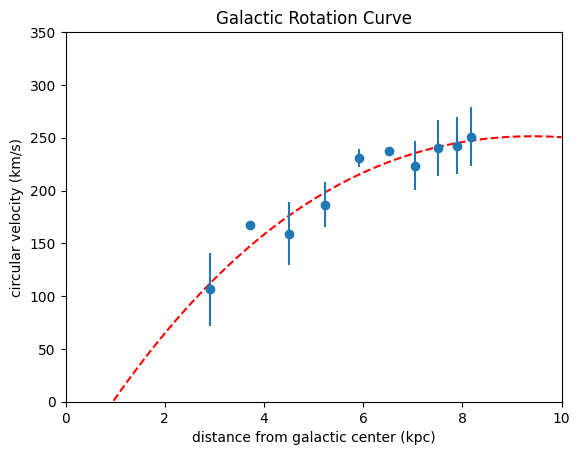

In [48]:
p_coeffs = np.polyfit(R, V, 3)
p = np.poly1d(p_coeffs)
R_fit = np.linspace(0, 10, 100)
V_fit = p(R_fit)
plt.plot(R_fit, V_fit, 'r--')

plt.errorbar(R, V, yerr=np.abs(noise_vr), fmt='o')
plt.xlim(0,10)
plt.ylim(0,350)
plt.title('Galactic Rotation Curve')
plt.xlabel('distance from galactic center (kpc)')
plt.ylabel('circular velocity (km/s)')
plt.show()

### calculate mass interior (Q9)

$M_R = \frac{V^2R}{G}$

In [45]:
G

<<class 'astropy.constants.codata2018.CODATA2018'> name='Gravitational constant' value=6.6743e-11 uncertainty=1.5e-15 unit='m3 / (kg s2)' reference='CODATA 2018'>

In [46]:
M = (( (V * u.km/u.s)**2 * (R * u.kpc) / G)).to(u.kg)
M

<Quantity [1.52028797e+40, 4.82818467e+40, 5.28035596e+40, 8.42763541e+40,
           1.44892889e+41, 1.70302900e+41, 1.62583255e+41, 2.00194443e+41,
           2.14285896e+41, 2.37670816e+41] kg>

In [47]:
table = {
    'longitude [deg]': galactic_numbers,
    'radius [kpc]': R,
    'velocity [km/s]': V,
    'mass [kg]': M
}

table = pd.DataFrame(table)
table

,longitude [deg],radius [kpc],velocity [km/s],mass [kg]
0,20,2.907171,106.354339,1.520288e+40
1,26,3.726155,167.412963,4.828185e+40
2,32,4.504314,159.237325,5.280356e+40
3,38,5.233123,186.637972,8.427635e+40
4,44,5.904596,230.385969,1.448929e+41
5,50,6.511378,237.849457,1.703029e+41
6,56,7.046819,223.392674,1.625833e+41
7,62,7.505055,240.202029,2.001944e+41
8,68,7.881063,242.511306,2.142859e+41
9,74,8.170724,250.833326,2.376708e+41
